---
# **Análisis y Predicción de la Viralidad del Contenido de TikTok mediante Machine Learning** 

### Trabajo de Fin de Máster - Universidad de Madrid (UCM)

**Autora:** Rocío Pérez Holgado.

---
## **Estructura del Proyecto**

* **Cuaderno 1:** `01_Carga_y_Exploracion.ipynb`.
* **Cuaderno 2:** `02_Limpieza_y_Feature_Engineering.ipynb`.
* **Cuaderno 3:** `03_Modelado_y_Optimizacion.ipynb`. **(Este cuaderno)**.

---
## **Índice - Cuaderno 3:**
1. **Importación de Librerías**.
2. **Carga del Dataset Preparado**.
3. **División Temporal en Entrenamiento y Prueba**.
4. **Preprocesamiento**.
5. **Comparación de Modelos Base**.
6. **Optimización del Mejor Modelo**.
7. **Evaluación Final**.
8. **Interpretabilidad**.
9. **Exportación del Modelo**.
10. **Conclusiones delo mod**

---
## **1. Importación de Librerías**

In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## **2. Carga del Dataset Preparado**

In [2]:
ruta_dataset = '../datos/dataset_modelo.parquet'

dataset_modelo = pd.read_parquet(ruta_dataset)

if 'fecha_publicacion' not in dataset_modelo.columns:
    raise ValueError(
        "No se ha encontrado 'fecha_publicacion'. Añádela en el Cuaderno 2 antes de exportar el dataset."
    )

dataset_modelo['fecha_publicacion'] = pd.to_datetime(
    dataset_modelo['fecha_publicacion']
)

print('Dimensiones:', dataset_modelo.shape)
display(dataset_modelo.head())

Dimensiones: (72127, 43)


,duration,desc_language,is_english,created_by_ai,music_selected_from,word_count,emoji_count,question_count,hashtag_count,speaking_rate,...,emocion_negativa,balance_emocional,log_follower_count,log_following_count,log_total_favorited,log_video_count,log_duration,log_word_count,seguidores_por_video,likes_historicos_por_video
0,20.067,un,0,0,edit_page_list,0,0,0,14,0.000000,...,0.175424,0.252141,7.843849,8.472823,8.168486,6.278521,3.047708,0.000000,4.791353,6.629699
1,45.467,en,1,0,original,218,6,4,6,9.039523,...,0.014346,0.820242,9.924417,5.826000,13.849657,6.311735,3.838742,5.389072,37.130909,1881.336364
2,66.467,en,1,0,video_capsule_recommend,2,0,0,0,0.000000,...,0.019240,0.895001,8.220134,6.167516,11.448238,7.691657,4.211639,1.098612,1.696665,42.820923
3,14.793,un,0,0,original,0,0,0,1,0.000000,...,0.093188,0.705462,8.220134,6.167516,11.448184,7.691200,2.759567,0.000000,1.697441,42.838208
4,14.001,en,1,0,single_song,11,2,0,9,0.000000,...,0.006311,0.953321,9.452580,6.440947,14.176216,5.683580,2.708117,2.484907,43.481229,4895.358362


---
## **3. División Temporal en Entrenamiento y Prueba**

Se reserva el 20 % más reciente de los vídeos como conjunto de prueba. La división cronológica evita entrenar con observaciones posteriores a las que se pretende predecir.

In [3]:
dataset_modelo = dataset_modelo.sort_values('fecha_publicacion').reset_index(drop=True)

punto_corte = int(len(dataset_modelo) * 0.80)

train_df = dataset_modelo.iloc[:punto_corte].copy()
test_df = dataset_modelo.iloc[punto_corte:].copy()

columnas_excluir = ['viral', 'fecha_publicacion']

X_train = train_df.drop(columns=columnas_excluir)
y_train = train_df['viral']

X_test = test_df.drop(columns=columnas_excluir)
y_test = test_df['viral']

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)
print('Última fecha de entrenamiento:', train_df['fecha_publicacion'].max())
print('Primera fecha de prueba:', test_df['fecha_publicacion'].min())
print('Porcentaje viral en entrenamiento:', round(y_train.mean() * 100, 2))
print('Porcentaje viral en prueba:', round(y_test.mean() * 100, 2))

Entrenamiento: (57701, 41)
Prueba: (14426, 41)
Última fecha de entrenamiento: 2024-10-07 00:00:00
Primera fecha de prueba: 2024-10-07 00:00:00
Porcentaje viral en entrenamiento: 9.8
Porcentaje viral en prueba: 11.05


---
## **4. Preprocesamiento**

Las variables numéricas se imputan con la mediana y se escalan. Las variables categóricas se imputan con su categoría más frecuente y se codifican mediante one-hot encoding. Todo el preprocesamiento se incorpora dentro de los pipelines para impedir fuga de información.

In [4]:
columnas_numericas = X_train.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

print('Variables numéricas:', len(columnas_numericas))
print('Variables categóricas:', len(columnas_categoricas))
print(columnas_categoricas)

try:
    codificador = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    codificador = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocesador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            Pipeline([
                ('imputacion', SimpleImputer(strategy='median')),
                ('escalado', StandardScaler())
            ]),
            columnas_numericas
        ),
        (
            'categoricas',
            Pipeline([
                ('imputacion', SimpleImputer(strategy='most_frequent')),
                ('codificacion', codificador)
            ]),
            columnas_categoricas
        )
    ],
    remainder='drop'
)


Variables numéricas: 37
Variables categóricas: 4
['desc_language', 'music_selected_from', 'topic', 'ratio_agrupado']


---
## **5. Comparación de Modelos Base**

Se comparan cuatro enfoques: 
1. una línea base sin aprendizaje
2. Regresión logística
3. Random Forest
4. Gradient Boosting.

La métrica principal será el área bajo la curva Precision-Recall (PR-AUC), adecuada para una variable objetivo con una clase viral minoritaria.
La validación cruzada respeta el orden temporal mediante `TimeSeriesSplit`.

In [5]:
modelos = {
    'Dummy': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', DummyClassifier(strategy='prior', random_state=RANDOM_STATE))
    ]),
    'Regresión logística': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),
    'HistGradientBoosting': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', HistGradientBoostingClassifier(
            max_iter=300,
            random_state=RANDOM_STATE
        ))
    ])
}

cv_temporal = TimeSeriesSplit(n_splits=4)

metricas = {
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

resultados = []

for nombre, pipeline in modelos.items():
    evaluacion = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_temporal,
        scoring=metricas,
        n_jobs=-1
    )

    resultados.append({
        'modelo': nombre,
        'PR-AUC media': evaluacion['test_pr_auc'].mean(),
        'ROC-AUC media': evaluacion['test_roc_auc'].mean(),
        'Precision media': evaluacion['test_precision'].mean(),
        'Recall medio': evaluacion['test_recall'].mean(),
        'F1 medio': evaluacion['test_f1'].mean()
    })

resultados_modelos = pd.DataFrame(resultados).sort_values(
    'PR-AUC media',
    ascending=False
).reset_index(drop=True)

display(resultados_modelos)

mejor_modelo_nombre = resultados_modelos.loc[0, 'modelo']
print('Mejor modelo base según PR-AUC:', mejor_modelo_nombre)

,modelo,PR-AUC media,ROC-AUC media,Precision media,Recall medio,F1 medio
0,Random Forest,0.684785,0.923138,0.812846,0.407204,0.542577
1,HistGradientBoosting,0.667475,0.922324,0.740044,0.465268,0.567784
2,Regresión logística,0.562250,0.905417,0.338035,0.834816,0.480966
3,Dummy,0.099242,0.500000,0.000000,0.000000,0.000000


Mejor modelo base según PR-AUC: Random Forest


---
## **6. Optimización del Mejor Modelo**

El modelo con mayor PR-AUC medio se optimiza mediante búsqueda aleatoria de hiperparámetros. La optimización usa únicamente el conjunto de entrenamiento y conserva la validación temporal.

In [6]:
busquedas = {
    'Regresión logística': RandomizedSearchCV(
        estimator=modelos['Regresión logística'],
        param_distributions={
            'modelo__C': [0.01, 0.1, 1, 10, 100],
            'modelo__class_weight': [None, 'balanced']
        },
        n_iter=10,
        scoring='average_precision',
        cv=cv_temporal,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True
    ),
    'Random Forest': RandomizedSearchCV(
        estimator=modelos['Random Forest'],
        param_distributions={
            'modelo__n_estimators': [300, 500, 700],
            'modelo__max_depth': [None, 10, 20, 30],
            'modelo__min_samples_split': [2, 5, 10],
            'modelo__min_samples_leaf': [1, 2, 4],
            'modelo__max_features': ['sqrt', 'log2'],
            'modelo__class_weight': ['balanced', 'balanced_subsample']
        },
        n_iter=15,
        scoring='average_precision',
        cv=cv_temporal,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True
    ),
    'HistGradientBoosting': RandomizedSearchCV(
        estimator=modelos['HistGradientBoosting'],
        param_distributions={
            'modelo__learning_rate': [0.03, 0.05, 0.1],
            'modelo__max_iter': [200, 300, 500],
            'modelo__max_leaf_nodes': [15, 31, 63],
            'modelo__min_samples_leaf': [10, 20, 30],
            'modelo__l2_regularization': [0, 0.1, 1]
        },
        n_iter=15,
        scoring='average_precision',
        cv=cv_temporal,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True
    )
}

if mejor_modelo_nombre == 'Dummy':
    raise ValueError('La línea base no debe ser el modelo final. Revisa el preprocesamiento y las variables predictoras.')

busqueda = busquedas[mejor_modelo_nombre]
busqueda.fit(X_train, y_train)

modelo_final = busqueda.best_estimator_

print('Mejor PR-AUC en validación temporal:', round(busqueda.best_score_, 4))
print('Mejores hiperparámetros:')
print(busqueda.best_params_)

Mejor PR-AUC en validación temporal: 0.6862
Mejores hiperparámetros:
{'modelo__n_estimators': 700, 'modelo__min_samples_split': 5, 'modelo__min_samples_leaf': 2, 'modelo__max_features': 'sqrt', 'modelo__max_depth': 30, 'modelo__class_weight': 'balanced_subsample'}


---
## **7. Evaluación Final sobre el Conjunto de Prueba**
El conjunto de prueba se utiliza una única vez, tras la selección y optimización del modelo. Se presentan métricas de clasificación, matriz de confusión y curvas ROC y Precision-Recall.

In [7]:
probabilidades_test = modelo_final.predict_proba(X_test)[:, 1]
predicciones_test = (probabilidades_test >= 0.50).astype(int)

print('PR-AUC:', round(average_precision_score(y_test, probabilidades_test), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, probabilidades_test), 4))
print('Precision:', round(precision_score(y_test, predicciones_test), 4))
print('Recall:', round(recall_score(y_test, predicciones_test), 4))
print('F1-score:', round(f1_score(y_test, predicciones_test), 4))

print('\nInforme de clasificación:')
print(classification_report(y_test, predicciones_test, target_names=['No viral', 'Viral']))

PR-AUC: 0.7439
ROC-AUC: 0.9355
Precision: 0.7738
Recall: 0.5665
F1-score: 0.6541

Informe de clasificación:
              precision    recall  f1-score   support

    No viral       0.95      0.98      0.96     12832
       Viral       0.77      0.57      0.65      1594

    accuracy                           0.93     14426
   macro avg       0.86      0.77      0.81     14426
weighted avg       0.93      0.93      0.93     14426



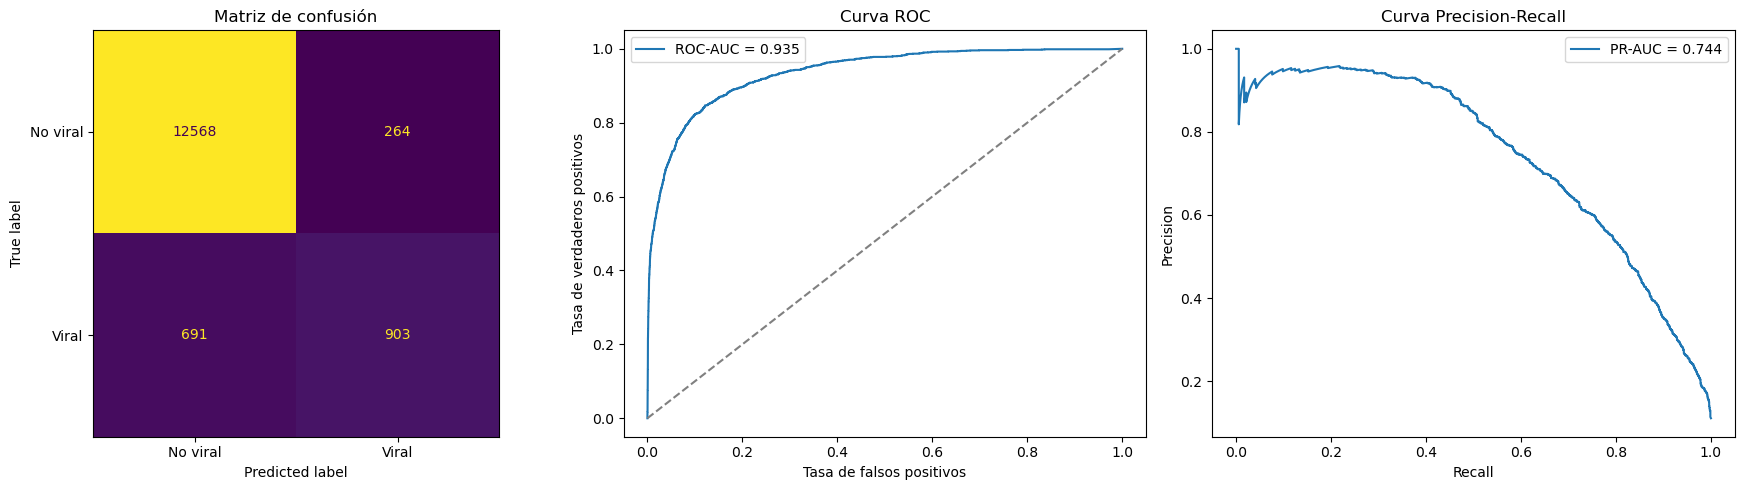

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, predicciones_test),
    display_labels=['No viral', 'Viral']
).plot(ax=ax[0], colorbar=False)
ax[0].set_title('Matriz de confusión')

fpr, tpr, _ = roc_curve(y_test, probabilidades_test)
ax[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, probabilidades_test):.3f}')
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_title('Curva ROC')
ax[1].set_xlabel('Tasa de falsos positivos')
ax[1].set_ylabel('Tasa de verdaderos positivos')
ax[1].legend()

precision, recall, _ = precision_recall_curve(y_test, probabilidades_test)
ax[2].plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, probabilidades_test):.3f}')
ax[2].set_title('Curva Precision-Recall')
ax[2].set_xlabel('Recall')
ax[2].set_ylabel('Precision')
ax[2].legend()

plt.tight_layout()
plt.show()

---
## **8. Interpretabilidad**

Se calcula la importancia por permutación sobre una muestra del conjunto de prueba. Esta técnica es válida para cualquier modelo y mide la pérdida de PR-AUC cuando se desordena una variable.

,variable,importancia_media,desviacion
40,likes_historicos_por_video,0.048846,0.009813
39,seguidores_por_video,0.024774,0.002150
18,follower_count,0.024274,0.004507
33,log_follower_count,0.023377,0.004044
35,log_total_favorited,0.021748,0.008621
20,total_favorited,0.016932,0.007960
22,hora_publicacion,0.010857,0.001245
34,log_following_count,0.007840,0.004105
19,following_count,0.006882,0.003490
1,desc_language,0.004287,0.005497


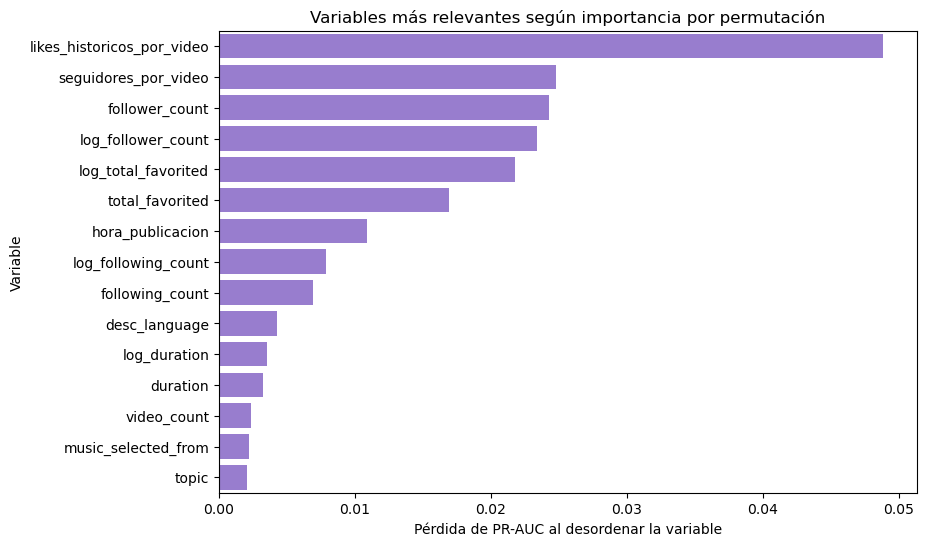

In [9]:
tamano_muestra = min(5000, len(X_test))
indices_muestra = X_test.sample(
    n=tamano_muestra,
    random_state=RANDOM_STATE
).index

importancia = permutation_importance(
    modelo_final,
    X_test.loc[indices_muestra],
    y_test.loc[indices_muestra],
    scoring='average_precision',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importancia_variables = pd.DataFrame({
    'variable': X_test.columns,
    'importancia_media': importancia.importances_mean,
    'desviacion': importancia.importances_std
}).sort_values('importancia_media', ascending=False)

display(importancia_variables.head(15))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importancia_variables.head(15),
    y='variable',
    x='importancia_media',
    color='mediumpurple'
)
plt.title('Variables más relevantes según importancia por permutación')
plt.xlabel('Pérdida de PR-AUC al desordenar la variable')
plt.ylabel('Variable')
plt.show()

---
## 9. **Exportación del modelo**

Se guardan el pipeline optimizado y las métricas obtenidas. El pipeline contiene tanto el preprocesamiento como el modelo y permite realizar predicciones sobre nuevos vídeos con la misma estructura de variables.

In [10]:
os.makedirs('../modelos', exist_ok=True)

ruta_modelo = '../modelos/modelo_viralidad_optimizado.joblib'
ruta_resultados = '../modelos/resultados_modelos.csv'

joblib.dump(modelo_final, ruta_modelo)
resultados_modelos.to_csv(ruta_resultados, index=False)

print('Modelo guardado en:', ruta_modelo)
print('Resultados guardados en:', ruta_resultados)

Modelo guardado en: ../modelos/modelo_viralidad_optimizado.joblib
Resultados guardados en: ../modelos/resultados_modelos.csv


---
## **7. Conclusiones del modelado**

**Rendimiento y selección del modelo:**
* **El modelo ganador: Random Forest** superó a HistGradientBoosting, Regresión Logística y al modelo base Dummy tanto en la fase de validación cruzada temporal como en la evaluación final.
* **Métrica objetivo (PR-AUC):** Alcanzó un **PR-AUC de 0.6848** en la fase base y se optimizó hasta **0.6862** mediante la búsqueda de hiperparámetros. En el conjunto de test independiente, la métrica alcanzó **0.7439**.

**Resultados en el Conjunto de Prueba (Test Set):**
* **PR-AUC:** 0.7439.
* **ROC-AUC:** 0.9355.
* **Precisión (Clase Viral):** 0.7738 (77.38%).
* **Recall / Sensibilidad (Clase Viral):** 0.5665 (56.65%).
* **F1-Score (Clase Viral):** 0.6541
* **Accuracy Global:** 0.93 (93.00%).

**Capacidad Predictiva del Modelo:**
* Baja tasa de falsos positivos: Cuando el modelo clasifica un vídeo como Viral, acertará el 77.38% de las veces (Alta Precisión). Esto es idóneo para evitar falsas falsas expectativas en estrategias de publicación.
* Detección de viralidad: El modelo es capaz de capturar y detectar el 56.65% de todos los vídeos que realmente se vuelven virales en la plataforma.
* Robustez temporal: Al realizar la partición cronológica (respetando la línea del tiempo) y validar con `TimeSeriesSplit`, el modelo demuestra no tener fuga de información (data leakage) y mantener una capacidad de generalización consistente hacia eventos y tendencias futuras.